In [182]:
#%%
import math
import numpy as np

import inspect
import importlib

import scipy.interpolate
from scipy import stats

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
from matplotlib import colormaps


plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

from fft_architecture_exploration                        import *

path_to_save_svg = "Saved_Data"


rng = np.random.default_rng(42)

In [183]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [184]:

import matplotlib.colors as mcolors

# Define base colors for each row
base_colors = {
    'red': '#f8333c',      # LightRed as base
    'blue': "#64ABD4",     # DeepBlue as base  
    'green': '#44af69',    # Green as base
    'orange': '#fcab10',   # Orange as base
    'purple': '#800080'    # Standard purple as base
}

# Create 10 nuances for each color by varying lightness
color_array = np.zeros((5, 10), dtype=object)

for i, (color_name, base_hex) in enumerate(base_colors.items()):
    base_rgb = mcolors.hex2color(base_hex)
    for j in range(10):
        # Create lighter/darker variations by scaling RGB values
        # Use a non-linear scaling for better visual distribution
        scale = 0.5 + 0.5 * (j / 9) ** 0.7  # 0.5 to 1.0 with curve
        if color_name == 'purple':
            # For purple, create a nice gradient from dark to light
            lightness = j / 9.0  # 0 to 1
            if j < 5:
                # Dark to medium purples
                r = 0.5 + 0.3 * (j / 4.0)
                b = 0.5 + 0.3 * (j / 4.0)
                g = 0.0 + 0.2 * (j / 4.0)
            else:
                # Medium to light purples
                r = 0.8 + 0.2 * ((j - 5) / 4.0)
                b = 0.8 + 0.2 * ((j - 5) / 4.0)
                g = 0.4 + 0.4 * ((j - 5) / 4.0)
            color_array[i, j] = mcolors.rgb2hex((r, g, b))
        else:
            # For other colors, scale from darker to lighter
            if j < 5:
                # Darker variations (scale down)
                scaled_rgb = tuple(max(0, min(1, c * (0.4 + 0.6 * (j / 4.0)))) for c in base_rgb)
            else:
                # Lighter variations (scale up)
                scaled_rgb = tuple(max(0, min(1, c * (1.0 + 0.6 * ((j - 5) / 4.0)))) for c in base_rgb)
            color_array[i, j] = mcolors.rgb2hex(scaled_rgb)

# Rename rows for clarity
color_names = ['red', 'blue', 'green', 'orange', 'purple']

In [185]:



importlib.reload(sys.modules['fft_architecture_exploration'])
from fft_architecture_exploration import * 

In [186]:


#----------------------------------------------------------------------------------

our_Area           = np.array([0.119    , 0.123    , 0.129    , 0.141    ] )     
our_NFFT           = np.array([4096     , 4096     , 4096     , 4096     ] )                 
our_Latency_pFFT   = np.array([98423    , 49250    , 32883    , 24723    ] )                 
our_Energy_pFFT    = np.array([3388.9   , 1922.4   , 1434.1   , 1197.6    ] ) *1e-9 

our_Latency        = our_Latency_pFFT   
our_Energy         = our_Energy_pFFT       
our_Speedup        = baseline_latency / our_Latency                                
our_Power          = our_Energy       / our_Latency  

our_area_ratio    = (our_Area+baseline_area)    / baseline_area
our_power_ratio   = our_Power   / baseline_power
our_energy_ratio  = our_Energy  / baseline_energy
our_latency_ratio = our_Latency / baseline_latency
our_speedup_ratio = 1/(our_latency_ratio)

#----------------------------------------------------------------------------------
soA_name          =           [ "Liu 18"  ]       #"Pereira 22" , "Berta. 21 ", "Gonz. 24",  "Yang 21", "Mahdavi 19", "Shih 18", "Tian 19"  , "Paul 25"  ]         #"Deng 23"
soA_type          =           [ "Memory-b"]       #"Memory-b"   , "Memory-b"  , "Memory-b",  "Pipel." , "Pipel."    , "Pipel." , "Memory-b" , "Memory-b" ]         #"Pipel." 
soa_Area_FFT       = np.array([   1.67    ] )     #   0.185     , 0.185       , 1.08      ,  1.83     , 0.57        , 1.09     ,0.84        , 3.8        ] )       #0.48                        
soa_NFFT           = np.array([   4096    ] )     #   256       , 1024        , 1024      ,  2048     , 2048        , 2048     ,4096        , 4096       ] )       #1024                       
soa_Latency_pFFT   = np.array([   768     ] )     #   1025      , 3005        , 1320      ,  2048     , 1200        , 2048     ,5120        , 605        ] )       #245                         
soa_Energy_pFFT    = np.array([  240.98   ] )*1e-9#   187.23    , 1054.78     , 297.92    ,  260.31   , 600.82      , 541.60   ,599.04      , 495.67     ] ) *1e-9 #22.94      

soa_Area           = scale_area    (area= soa_Area_FFT,        nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)    
soa_Latency        = scale_latency (latency= soa_Latency_pFFT, nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)                      
soa_Energy         = soa_Energy_pFFT  * (4096*12/(soa_NFFT*np.log2(soa_NFFT)))     

soa_Speedup        = baseline_latency / soa_Latency                                
soa_Power          = soa_Energy       / soa_Latency  

soa_area_ratio    = (soa_Area+baseline_area)    / baseline_area
soa_power_ratio   = soa_Power   / baseline_power
soa_energy_ratio  = soa_Energy  / baseline_energy
soa_latency_ratio = soa_Latency / baseline_latency
soa_speedup_ratio = 1/(soa_latency_ratio)

In [218]:
analysis_Mem_type  = np.array([0]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
analysis_nMem_type = len(analysis_Mem_type)

In [219]:

alpha_studied = np.linspace(0.01, 1, 100,endpoint=False)

# ----------------------------------------------------------------------
# 2a. DERIVE RATIOS 
# ----------------------------------------------------------------------

theor_asi_res  = np.zeros((len(alpha_studied),3,arch_Dim,analysis_nMem_type))
theor_ncf_res  = np.zeros((len(alpha_studied),3,arch_Dim,analysis_nMem_type,2))
for k in range(3):
    for i in range(arch_Dim):
        for j in analysis_Mem_type:
            theor_asi_res[:,k,i,j]  = asi_function (alpha=alpha_studied, area_ratio=theor_area_ratio[k,i,j], power_ratio=theor_power_ratio[k,i,j],print=False)
            theor_ncf_res[:,k,i,j,0]= (theor_area_ratio[k,i,j]* (alpha_studied)) +  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
            theor_ncf_res[:,k,i,j,1]= (theor_area_ratio[k,i,j]* (alpha_studied)) +  (theor_power_ratio [k,i,j]* (1-alpha_studied))

# ----------------------------------------------------------------------

our_asi_res  = np.zeros((len(alpha_studied),len(our_area_ratio)))
our_ncf_res  = np.zeros((len(alpha_studied),len(our_area_ratio),2))
for i in range(our_area_ratio.shape[0]):
    print(f"THEOR {i}: area_ratio={our_area_ratio[i]:.2f}, area={our_Area[i]:.4f},  power_ratio={our_power_ratio[i]:.2f}, energy_ratio={our_energy_ratio[i]:.2f}, speedup={our_speedup_ratio[i]:.2f}")
    our_asi_res[:,i]  = asi_function (alpha=alpha_studied, area_ratio=our_area_ratio[i], power_ratio=our_power_ratio[i],print=False)
    our_ncf_res[:,i,0]= (our_area_ratio[i]* (alpha_studied)) +  (our_energy_ratio[i]* (1-alpha_studied))
    our_ncf_res[:,i,1]= (our_area_ratio[i]* (alpha_studied)) +  (our_power_ratio[i] * (1-alpha_studied))

# ----------------------------------------------------------------------

soa_asi_res  = np.zeros((len(alpha_studied),len(soa_area_ratio)))
soa_ncf_res  = np.zeros((len(alpha_studied),len(soa_area_ratio),2))
for i in range(soa_area_ratio.shape[0]):
    print(f"SOA {i}: area_ratio={soa_area_ratio[i]:.2f},area={soa_Area[i]:.4f}, power_ratio={soa_power_ratio[i]:.2f}, energy_ratio={soa_energy_ratio[i]:.2f}, speedup={soa_speedup_ratio[i]:.2f}")
    soa_asi_res[:,i]  = asi_function (alpha=alpha_studied, area_ratio=soa_area_ratio[i], power_ratio=soa_power_ratio[i],print=False)
    soa_ncf_res[:,i,0]= (soa_area_ratio[i]* (alpha_studied)) +  (soa_energy_ratio[i]* (1-alpha_studied))
    soa_ncf_res[:,i,1]= (soa_area_ratio[i]* (alpha_studied)) +  (soa_power_ratio[i] * (1-alpha_studied))

THEOR 0: area_ratio=1.01, area=0.1190,  power_ratio=0.47, energy_ratio=0.14, speedup=3.33
THEOR 1: area_ratio=1.01, area=0.1230,  power_ratio=0.53, energy_ratio=0.08, speedup=6.65
THEOR 2: area_ratio=1.01, area=0.1290,  power_ratio=0.60, energy_ratio=0.06, speedup=9.97
THEOR 3: area_ratio=1.01, area=0.1410,  power_ratio=0.66, energy_ratio=0.05, speedup=13.25
SOA 0: area_ratio=1.17,area=1.6700, power_ratio=4.29, energy_ratio=0.01, speedup=426.67


Text(0.5, 1.0, 'State-of-the-art KPIs\n (Marker size ∝ Area)')

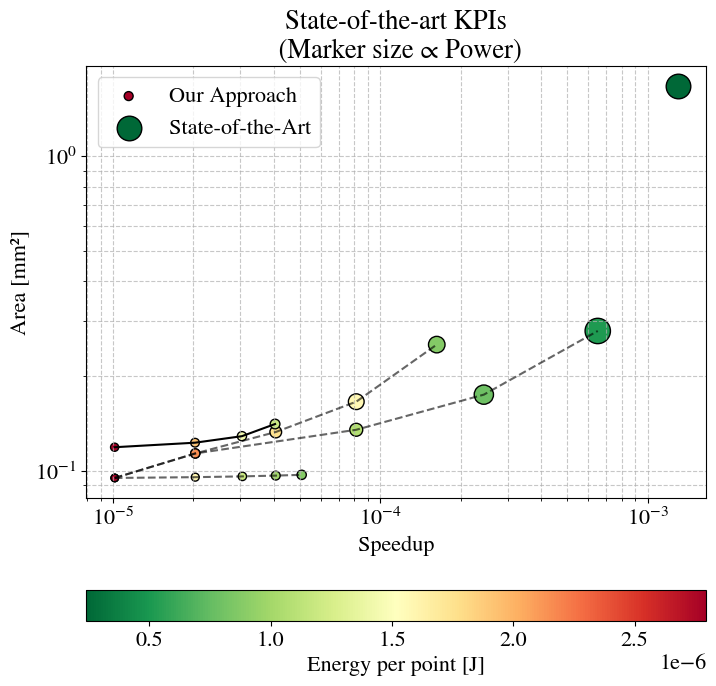

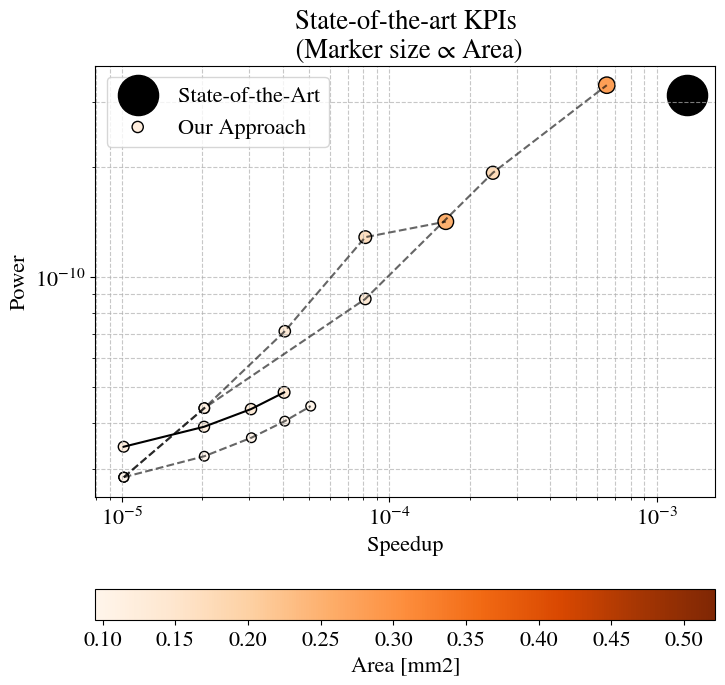

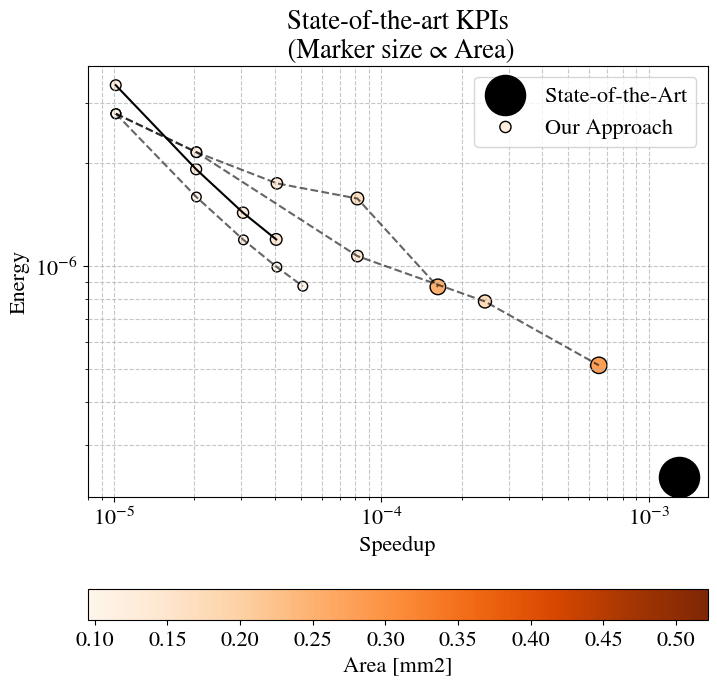

In [221]:
fig, ax = plt.subplots(1,1, figsize=(8, 8))

for i in analysis_Mem_type:
    for j in range(3):
        sc = ax.scatter(    1/theor_Latency[j,:,i],     theor_Area[j,:,i], c=     theor_Energy[j,:,i],  cmap='RdYlGn_r', s=    theor_Power[j,:,i]*4e12, vmin =np.min(soa_Energy),vmax = np.max(theor_Energy), alpha=1, marker = '.', edgecolors="black")
        ax.plot(1/theor_Latency[j,:,i], theor_Area[j,:,i], color = 'black', alpha=0.6, linestyle ='--')

sc = ax.scatter(1/our_Latency  , our_Area  , c= our_Energy  ,  cmap='RdYlGn_r', s=our_Power*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.', edgecolors="black", label="Our Approach")
sc = ax.scatter(1/soa_Latency  , soa_Area  , c= soa_Energy  ,  cmap='RdYlGn_r', s=soa_Power*4e12, vmin =np.min(soa_Energy),vmax = np.max(pipe_theor_Energy), alpha=1, marker = '.', edgecolors="black", label="State-of-the-Art")
ax.plot(1/our_Latency    , our_Area  , color = "black")

fig.colorbar(sc, ax=ax, label='Energy per point [J]', location='bottom')
ax.legend()

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Area [mm²]')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n (Marker size ∝ Power)')

######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(8, 8))


for i in analysis_Mem_type:
    for j in range(3):
        sc = ax.scatter(    1/theor_Latency[j,:,i],     theor_Power[j,:,i], c=     theor_Area[j,:,i],  cmap='Oranges', s=    theor_Area[j,:,i]*2e3, vmin =np.min(theor_Area),vmax = np.max(theor_Area), alpha=1, marker = '.', edgecolors="black")
        ax.plot(1/theor_Latency[j,:,i], theor_Power[j,:,i], color = 'black', alpha=0.6, linestyle ='--')

ax.plot(1/our_Latency    , our_Power  , color = "black")
sc = ax.scatter(1/soa_Latency  , soa_Power  , c= "black",                                                                                      s=soa_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="State-of-the-Art")
sc = ax.scatter(1/our_Latency  , our_Power  , c= our_Area  ,  cmap='Oranges',vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), s=our_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="Our Approach")

fig.colorbar(sc, ax=ax, label='Area [mm2]', location='bottom')
ax.legend()

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Power')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n (Marker size ∝ Area)')


######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(8, 8))


for i in analysis_Mem_type:
    for j in range(3):
        sc = ax.scatter(    1/theor_Latency[j,:,i],     theor_Energy[j,:,i], c=     theor_Area[j,:,i],  cmap='Oranges', s=    theor_Area[j,:,i]*2e3, vmin =np.min(theor_Area),vmax = np.max(theor_Area), alpha=1, marker = '.', edgecolors="black")
        ax.plot(1/theor_Latency[j,:,i], theor_Energy[j,:,i], color = 'black', alpha=0.6, linestyle ='--')

ax.plot(1/our_Latency    , our_Energy  , color = "black")
sc = ax.scatter(1/soa_Latency  , soa_Energy  , c= "black",                                                                                      s=soa_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="State-of-the-Art")
sc = ax.scatter(1/our_Latency  , our_Energy  , c= our_Area  ,  cmap='Oranges',vmin =np.min(pipe_theor_Area),vmax = np.max(pipePara_theor_Area), s=our_Area*2e3, alpha=1, marker = '.', edgecolors="black", label="Our Approach")

fig.colorbar(sc, ax=ax, label='Area [mm2]', location='bottom')

ax.legend()

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Energy')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n (Marker size ∝ Area)')

C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_4504\1996720566.py:24: UserWarning:

Attempt to set non-positive xlim on a log-scaled axis will be ignored.



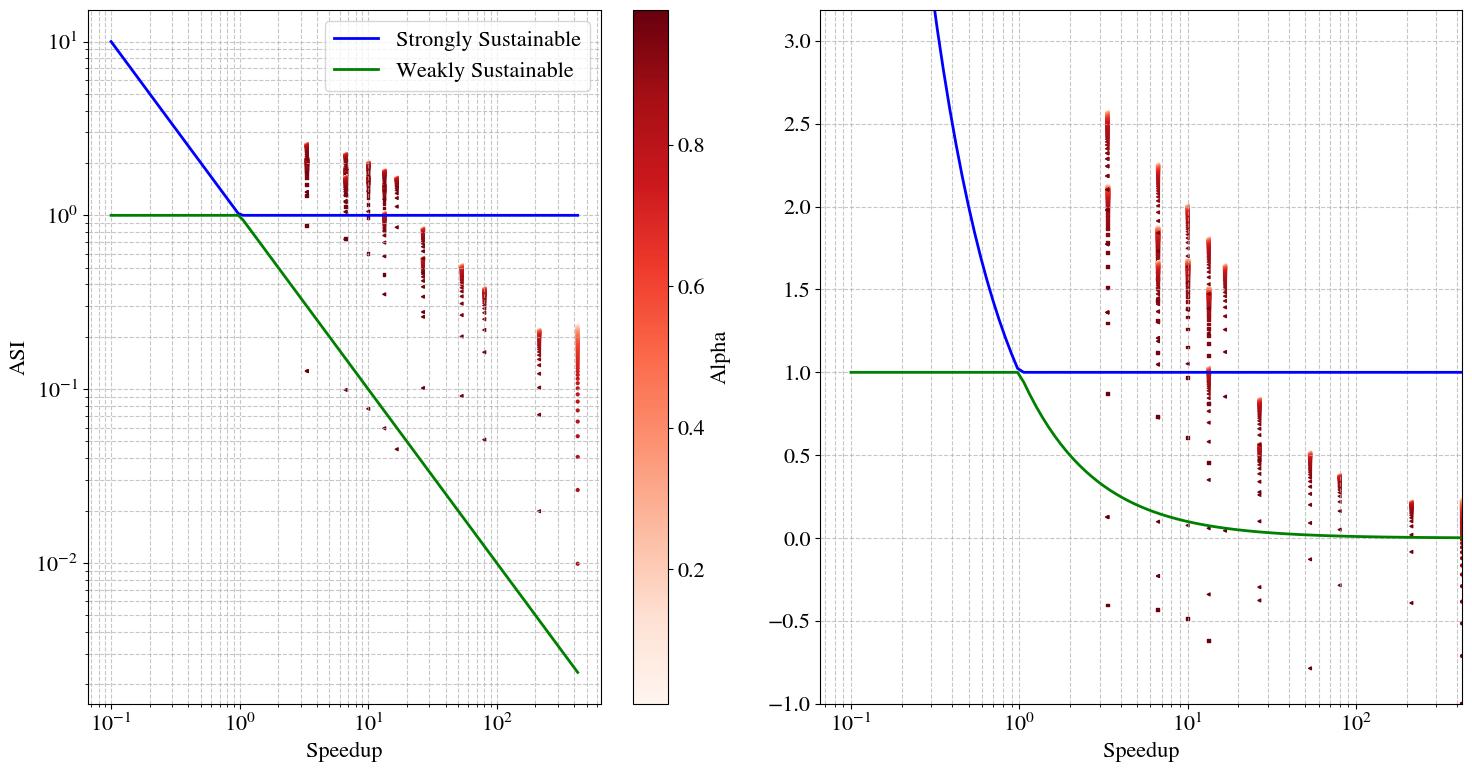

In [223]:
# ASI Framework separations
speedup_space = np.logspace(-1, np.log10(np.max(soa_speedup_ratio)), 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1


# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(15, 8))
ax[0].set_ylabel('ASI')
ax[0].loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax[0].loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')
ax[1].plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
ax[1].plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

ax[1].set_xscale('log')

ax[0].set_xlabel('Speedup')
ax[1].set_xlabel('Speedup')
ax[1].set_ylim([-1,np.max(our_asi_res)*1.5])
ax[1].set_xlim([0,np.max(soa_speedup_ratio)])

ax[0].grid(True, which='both', linestyle='--', alpha=0.7)
ax[1].grid(True, which='both', linestyle='--', alpha=0.7)

#Add our accelerator
for i in range(soa_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[i],   np.maximum(soa_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4)
    p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[i],   np.maximum(soa_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4)
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='s')
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='s')


for k in range(3):
    for i in range(arch_Dim):
        for j in analysis_Mem_type:
            p = ax[0].scatter(np.ones(len(alpha_studied))*theor_speedup_ratio[k,i,j],   np.maximum(theor_asi_res[:,k,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')
            p = ax[1].scatter(np.ones(len(alpha_studied))*theor_speedup_ratio[k,i,j],   np.maximum(theor_asi_res[:,k,i,j],-1),   c=alpha_studied,cmap="Reds",  s=4, marker='<')

ax[0].legend()
# Add legend
fig.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


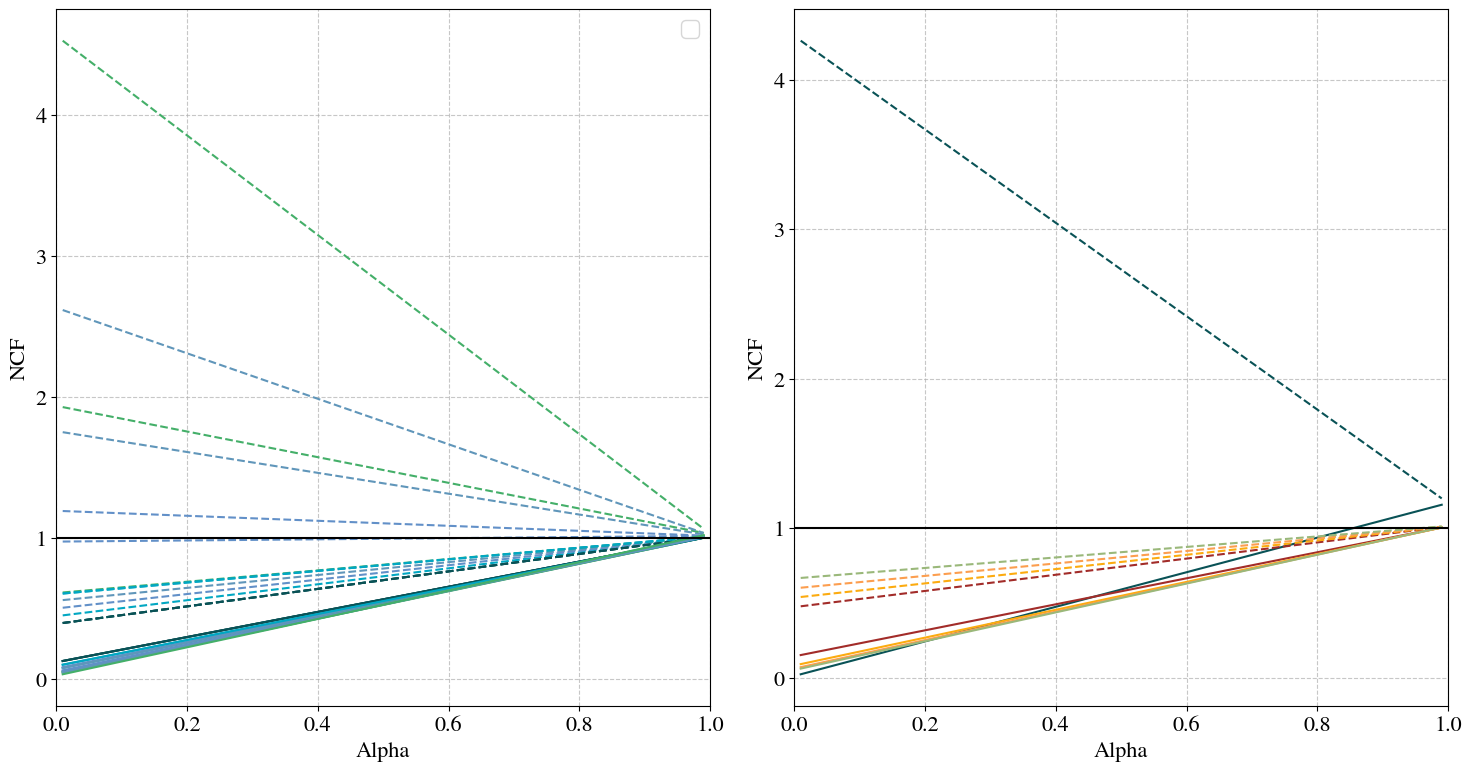

In [225]:
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(15, 8))


ax[0].set_xlabel('ALpha')
ax[1].set_xlabel('ALpha')

ax[0].grid(True, which='both', linestyle='--', alpha=0.7)
ax[1].grid(True, which='both', linestyle='--', alpha=0.7)

# Add our accelerator

for k in range(3):
    for i in range(arch_Dim):
        for j in analysis_Mem_type:
            p = ax[0].plot(alpha_studied,   theor_ncf_res[:,k,i,j,0],   color = listColor[i] , linestyle ='-')
            p = ax[0].plot(alpha_studied,   theor_ncf_res[:,k,i,j,1],   color = listColor[i] , linestyle ='--')

# Add our accelerator
for i in range(soa_area_ratio.shape[0]):
    p = ax[1].plot(alpha_studied,   soa_ncf_res[:,i,0],   color = listColor[i] , linestyle ='-')
    p = ax[1].plot(alpha_studied,   soa_ncf_res[:,i,1],   color = listColor[i] , linestyle ='--')


for i in range(our_area_ratio.shape[0]):
    p = ax[1].plot(alpha_studied,   our_ncf_res[:,i,0],   color = listColor[i+6] , linestyle ='-')
    p = ax[1].plot(alpha_studied,   our_ncf_res[:,i,1],   color = listColor[i+6] , linestyle ='--')

ax[0].hlines(y=1,xmin = 0, xmax=1, color= "black")
ax[1].hlines(y=1,xmin = 0, xmax=1, color= "black")

ax[0].set_xlim([0,1])
ax[1].set_xlim([0,1])

ax[0].set_xlabel("Alpha")
ax[1].set_xlabel("Alpha")
ax[0].set_ylabel("NCF")
ax[1].set_ylabel("NCF")
ax[0].legend()
# Add legend
fig.tight_layout()
plt.show()


# Monte Carlo from architecture exploration

In [226]:
N = 10000

mc_Mem_type  = np.array([0]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
mc_nMem_type = len(mc_Mem_type)

# Random architecture selection
mc_mem  = rng.integers(low=0,high=mc_nMem_type, size= N)
mc_strat= rng.integers(low=0,high=3,            size= N)
mc_arch = rng.integers(low=0,high=arch_Dim,     size= N)

mc_mem_idx = mc_Mem_type[mc_mem]

mc_area_overhead     = theor_Area          [mc_strat,mc_arch,mc_mem_idx] 
mc_power_ratio       = theor_power_ratio   [mc_strat,mc_arch,mc_mem_idx] 
mc_energy_ratio      = theor_energy_ratio  [mc_strat,mc_arch,mc_mem_idx] 
mc_speedup_ratio     = theor_speedup_ratio [mc_strat,mc_arch,mc_mem_idx] 

# Impairment to speedup
mc_speedup_factor = rng.uniform(low=0.9, high=1, size=N)
mc_speedup_ratio  = mc_speedup_ratio*mc_speedup_factor


# Impairment to energy
mc_energy_factor = rng.uniform(low=1, high=1.5, size=N)
mc_energy_ratio  = mc_energy_ratio*mc_energy_factor


mc_power_ratio = (mc_energy_ratio) * mc_speedup_ratio

# Impairment to area
mc_area_factor = rng.uniform(low=1, high=1.5, size=N)
mc_area_ratio  = ((mc_area_overhead*mc_area_factor)+baseline_area)/baseline_area

mc_alpha = rng.uniform(low=0.001, high=0.99, size=N)

# ----------------------------------------------------------------------
# 3. XASI METRIC
# ----------------------------------------------------------------------
mc_asi_res     = asi_function(alpha=mc_alpha, area_ratio=mc_area_ratio, power_ratio=mc_power_ratio,print=False)

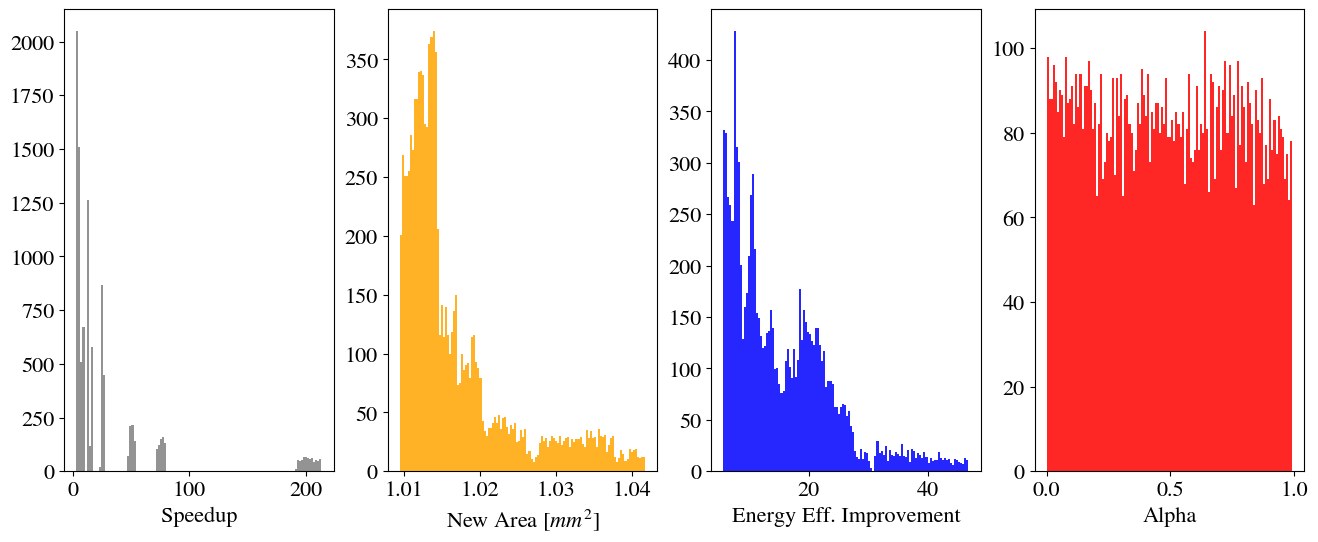

Text(0.5, 1.0, 'Outcome across design space\n(color = sustainability outcome)')

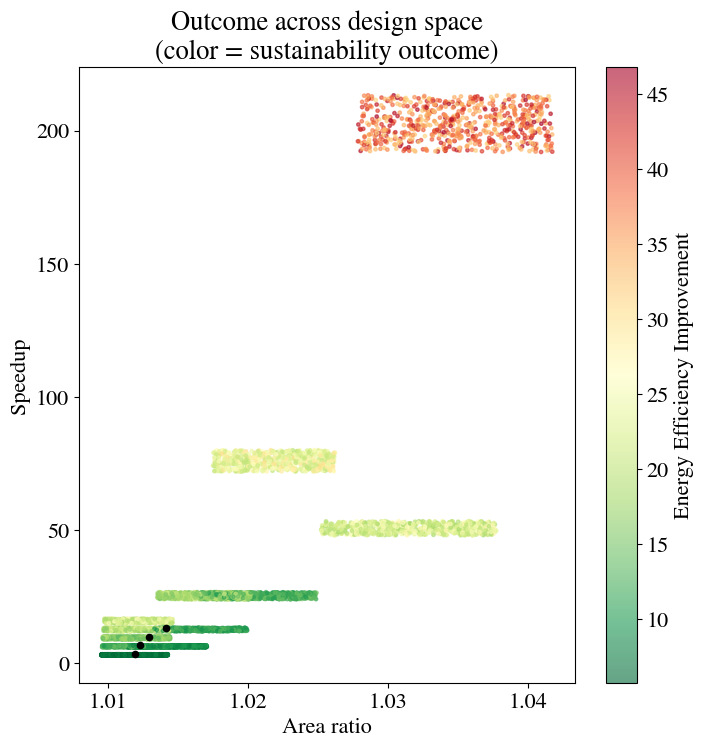

In [227]:

fig, ax = plt.subplots(1,4, figsize=(16,6))

ax[0].hist(mc_speedup_ratio, bins=120, color='Gray', alpha=0.85, edgecolor='none')
ax[0].set_xlabel('Speedup')
ax[1].hist(mc_area_ratio, bins=120, color='Orange', alpha=0.85, edgecolor='none')
ax[1].set_xlabel('New Area [$mm^2$]')
ax[2].hist(1/mc_energy_ratio, bins=120, color='Blue', alpha=0.85, edgecolor='none')
ax[2].set_xlabel('Energy Eff. Improvement')
ax[3].hist(mc_alpha, bins=120, color='Red', alpha=0.85, edgecolor='none')
ax[3].set_xlabel('Alpha')

plt.show()

##############################################################################################
fig, axes = plt.subplots(1,1, figsize=(8, 8))

ax = axes #axes[1, 0]
sc = ax.scatter(mc_area_ratio, mc_speedup_ratio, c=1/mc_energy_ratio,
                 cmap='RdYlGn_r', s=6, vmin=np.min(1/mc_energy_ratio), vmax=np.max(1/mc_energy_ratio), alpha=0.6)

plt.colorbar(sc, ax=ax, label='Energy Efficiency Improvement')

for i in range(our_Area.shape[0]):
    ax.scatter (our_area_ratio[i], our_Speedup[i], s = 20, c ='black')

ax.set_xlabel('Area ratio')
ax.set_ylabel('Speedup')
ax.set_title('Outcome across design space\n(color = sustainability outcome)')



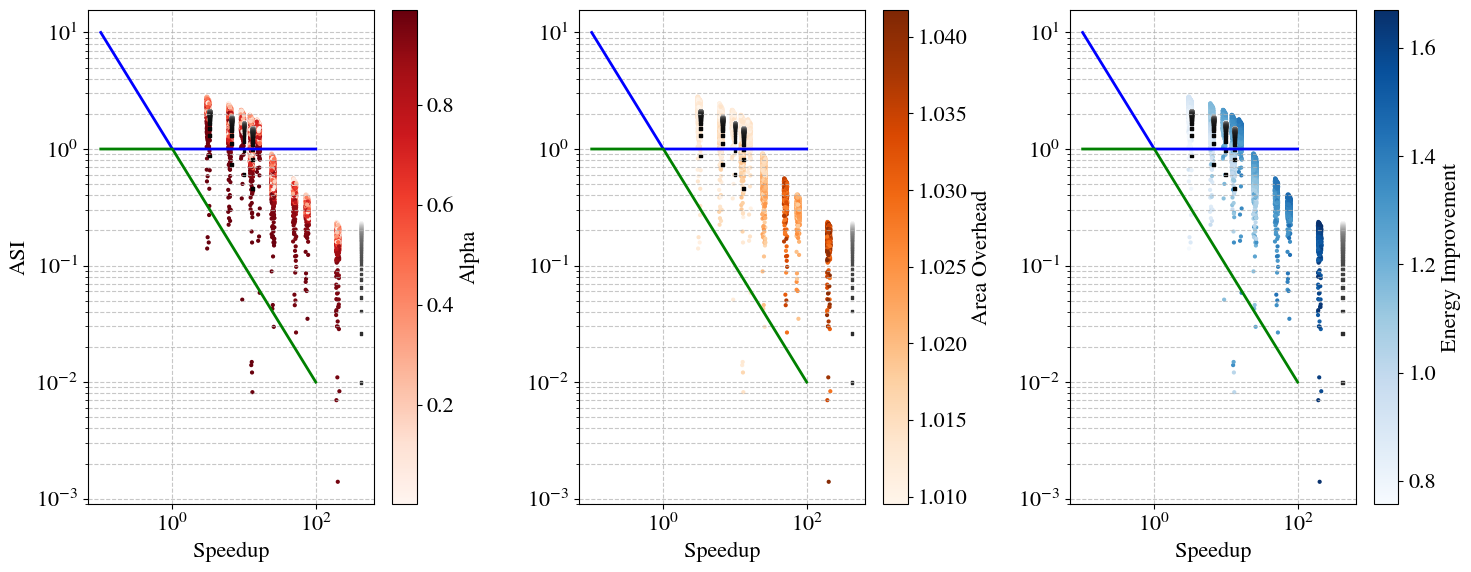

In [228]:
# ASI Framework separations
speedup_space = np.logspace(-1, 2, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(mc_speedup_ratio,   mc_asi_res,   c=mc_area_ratio,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(mc_speedup_ratio,   mc_asi_res,   c=np.log10(1/mc_energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')


# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[2].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')

p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[2].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[0],   np.maximum(soa_asi_res[:,0],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
# Add legend
fig.tight_layout()
plt.show()


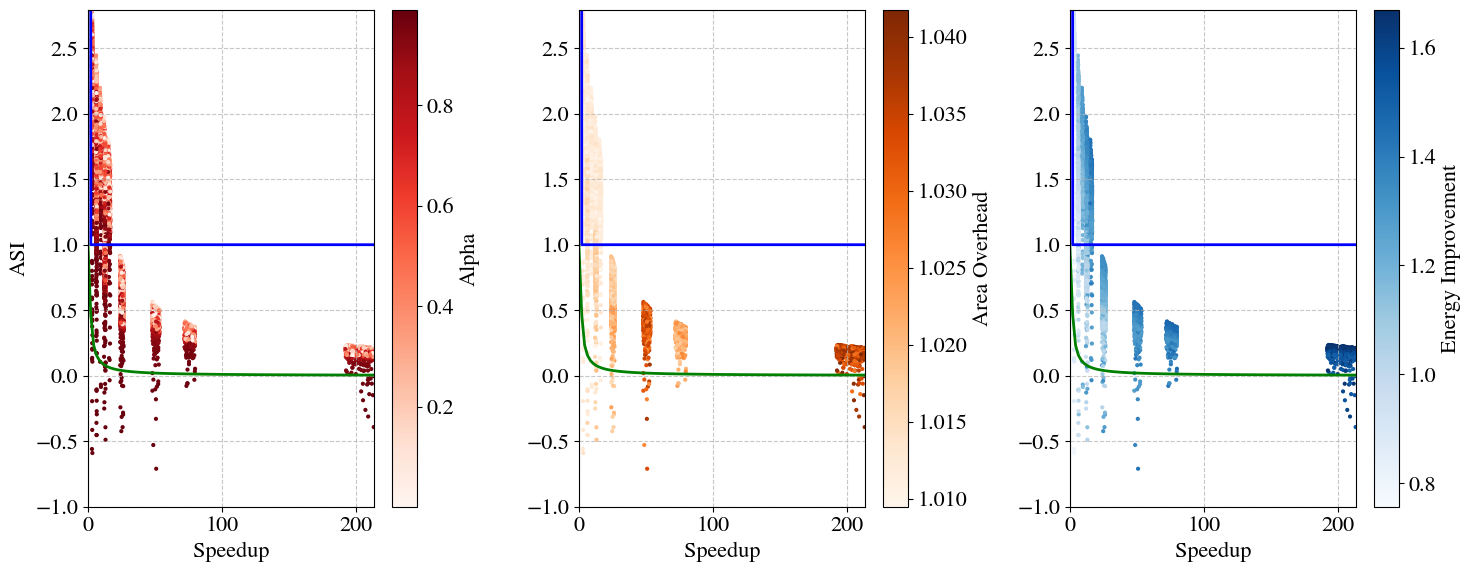

In [214]:
# ASI Framework separations
speedup_space = np.linspace(0.01, np.max(mc_speedup_ratio), 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.plot(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.plot(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.set_ylim([-1,np.max(mc_asi_res)])
    this_ax.set_xlim([0,np.max(mc_speedup_ratio)])
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(mc_speedup_ratio,   np.maximum(mc_asi_res,-1),   c=mc_alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(mc_speedup_ratio,   np.maximum(mc_asi_res,-1),   c=mc_area_ratio,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(mc_speedup_ratio,   np.maximum(mc_asi_res,-1),   c=np.log10(1/mc_energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')

# Add legend
fig.tight_layout()
plt.show()


In [229]:

alpha_star = asi_critical_alpha(area_ratio=mc_area_ratio, power_ratio=mc_power_ratio, speedup=mc_speedup_ratio)
region     = asi_classify(asi=mc_asi_res, speedup=mc_speedup_ratio)


valid_a_star = alpha_star[~np.isnan(alpha_star)]
region_counts = {r: (region == r).mean() for r in ['strong', 'weak', 'unsust']}

print("Alpha-independent region breakdown (hardware uncertainty only):")
for r, label in [('strong', 'Strongly sustainable (wins on area AND energy)'),
                  ('weak', 'Weakly sustainable (trade-off, alpha decides)'),
                  ('unsust', 'Unsustainable (loses on area AND energy)')]:
    print(f"  {label:55s}: {region_counts[r]*100:5.1f}%")

Alpha-independent region breakdown (hardware uncertainty only):
  Strongly sustainable (wins on area AND energy)         :  60.1%
  Weakly sustainable (trade-off, alpha decides)          :  39.2%
  Unsustainable (loses on area AND energy)               :   0.7%


In [216]:
inputs = {
    
    'Acc. Strategy'         : mc_strat,
    'Acc. Arch. Comp.'      : mc_arch,
    'Acc. Mem. Type'        : mc_mem,

    'Area overhead frac'    : mc_area_overhead,
    'Speedup'               : mc_speedup_ratio,
    'Energy Eff. Improv'    : 1/mc_energy_ratio,
    'Power ratio'           : mc_power_ratio,
    'Alpha'                 : mc_alpha,
}

sensitivities = {}
for name, x in inputs.items():
    rho, _ = stats.spearmanr(x, mc_asi_res)
    sensitivities[name] = rho

print("Sensitivity of NCF_ratio to each input (Spearman rho):")
for name, rho in sorted(sensitivities.items(), key=lambda kv: -(kv[1])):
    print(f"  {name:25s}: {rho:+.3f}")

Sensitivity of NCF_ratio to each input (Spearman rho):
  Alpha                    : -0.127
  Acc. Strategy            : -0.441
  Acc. Arch. Comp.         : -0.738
  Acc. Mem. Type           : +nan
  Energy Eff. Improv       : -0.622
  Speedup                  : -0.884
  Area overhead frac       : -0.931
  Power ratio              : -0.972


(0.0, 2.653274948492467)

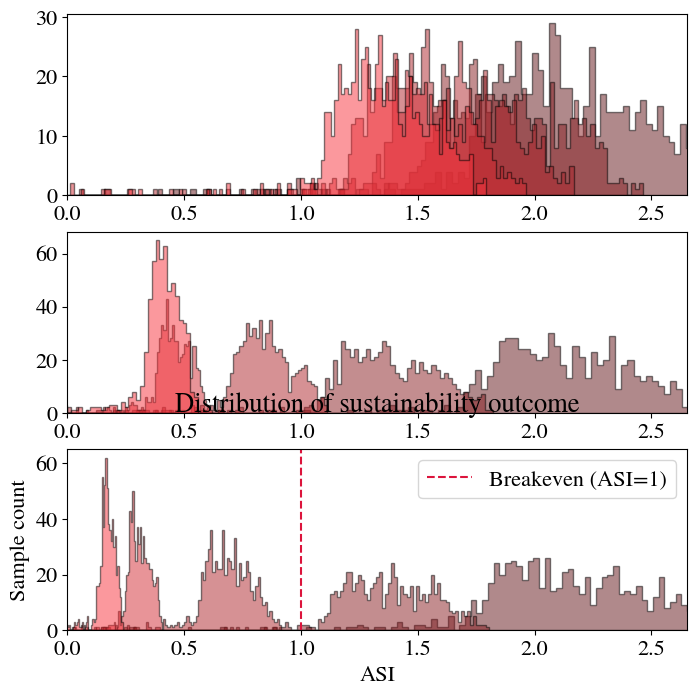

In [230]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))

# (a) NCF ratio distribution
ax = axes
for i in range(3):
    for j in range(arch_Dim):
        ax[i].hist(mc_asi_res[np.where((mc_strat==i) & (mc_arch==j)) ], bins=120, color=color_array[0,j] , alpha=0.5,histtype='stepfilled', ec='black')

ax[2].set_xlabel('ASI')
ax[2].set_ylabel('Sample count')
ax[2].set_title(f'Distribution of sustainability outcome\n')
ax[2].axvline(1.0, color='crimson', linestyle='--', linewidth=1.5, label='Breakeven (ASI=1)')
ax[2].legend()
ax[0].set_xlim(0, np.percentile(mc_asi_res, 99.5))
ax[1].set_xlim(0, np.percentile(mc_asi_res, 99.5))
ax[2].set_xlim(0, np.percentile(mc_asi_res, 99.5))

Text(0.5, 1.0, 'Sensitivity ranking')

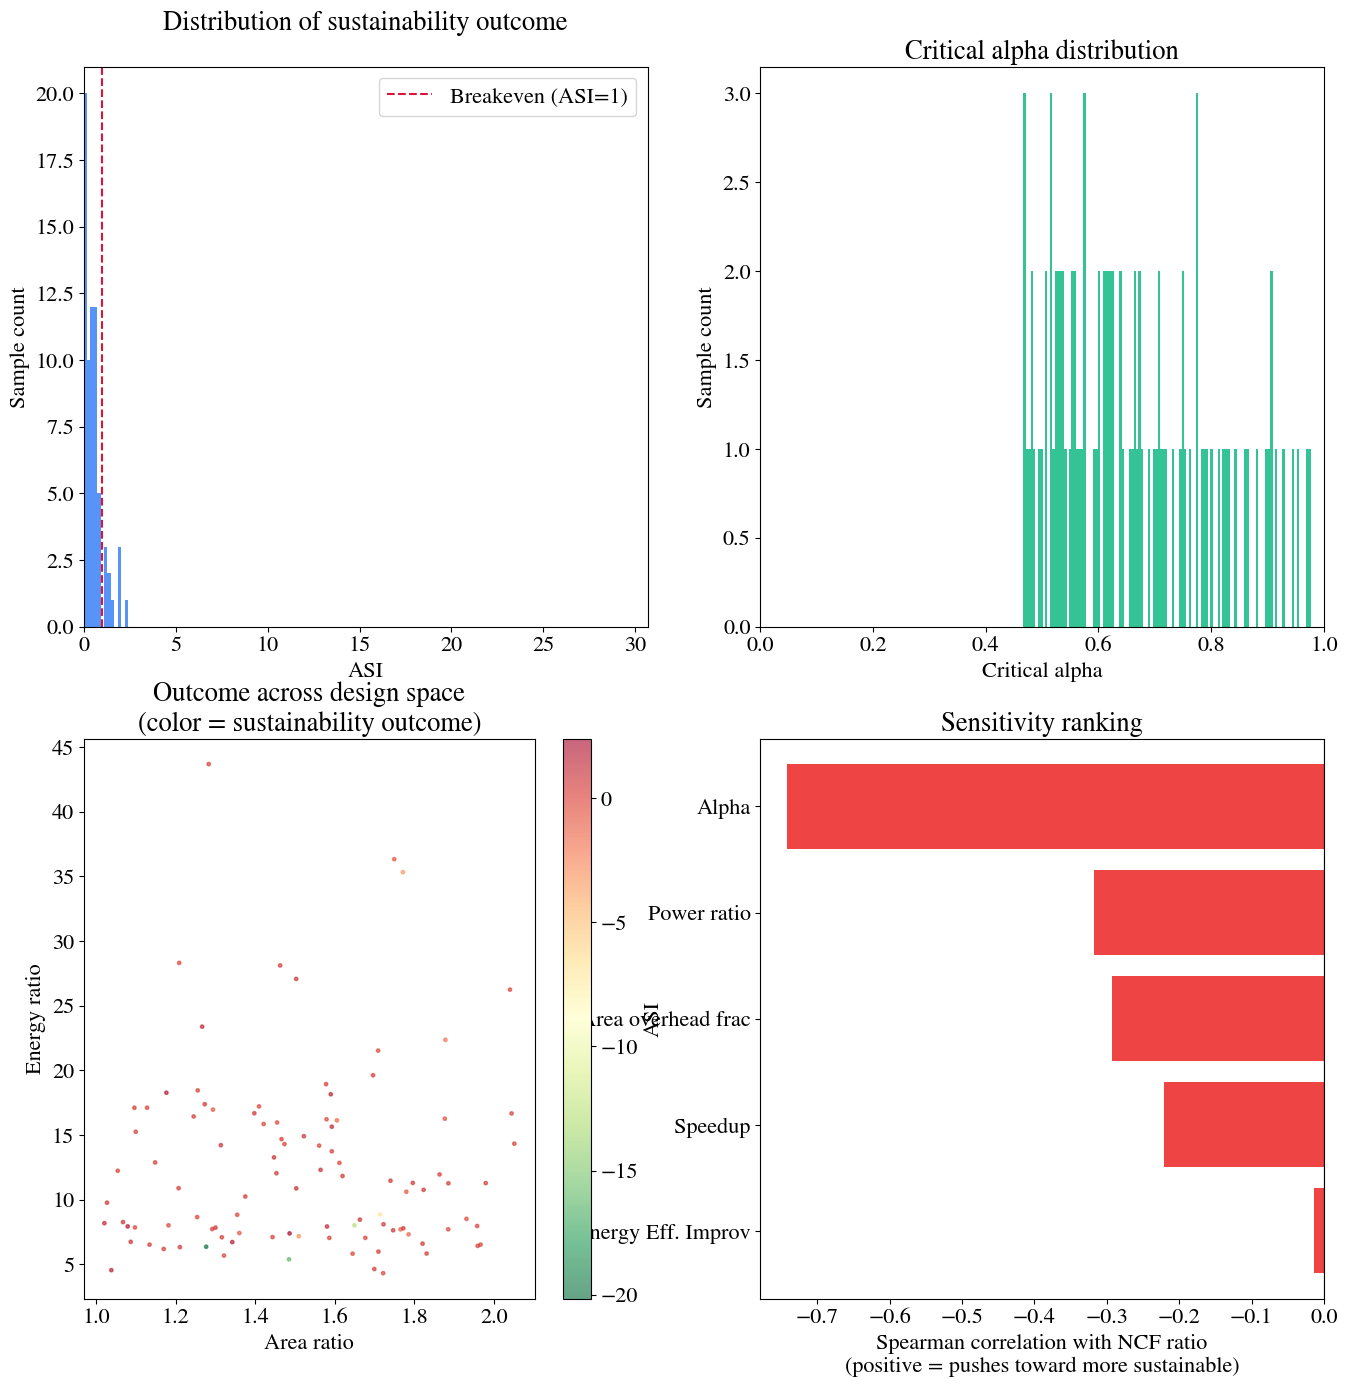

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# (a) NCF ratio distribution
ax = axes[0, 0]
ax.hist(mc_asi_res, bins=120, color='#3b82f6', alpha=0.85, edgecolor='none')
ax.set_xlabel('ASI')
ax.set_ylabel('Sample count')
ax.set_title(f'Distribution of sustainability outcome\n')

ax.axvline(1.0, color='crimson', linestyle='--', linewidth=1.5,
           label='Breakeven (ASI=1)')
ax.legend()
ax.set_xlim(0, np.percentile(mc_asi_res, 99.5))

# (b) Critical alpha* distribution
ax = axes[0, 1]
ax.hist(valid_a_star, bins=120, color='#10b981', alpha=0.85, edgecolor='none')
ax.set_xlabel('Critical alpha')
ax.set_ylabel('Sample count')
ax.set_title('Critical alpha distribution')
ax.set_xlim(0, 1)

# (c) Region map: area overhead vs speedup, colored by NCF ratio
ax = axes[1, 0]
sc = ax.scatter(mc_area_ratio, 1/mc_energy_ratio, c=mc_asi_res,
                 cmap='RdYlGn_r', s=6, vmin=np.min(mc_asi_res), vmax=np.max(mc_asi_res), alpha=0.6)
plt.colorbar(sc, ax=ax, label='ASI')
ax.set_xlabel('Area ratio')
ax.set_ylabel('Energy ratio')
ax.set_title('Outcome across design space\n(color = sustainability outcome)')

# (d) Tornado / sensitivity chart
ax = axes[1, 1]
names_sorted = sorted(sensitivities, key=lambda k: abs(sensitivities[k]))
vals_sorted = [sensitivities[k] for k in names_sorted]
colors = ['#ef4444' if v < 0 else '#3b82f6' for v in vals_sorted]
ax.barh(names_sorted, vals_sorted, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Spearman correlation with NCF ratio\n'
              '(positive = pushes toward more sustainable)')
ax.set_title('Sensitivity ranking')


# Monte Carlo based on state-of-the-art

In [ ]:
ref_point_soa = soA_name.index("Liu 18")

ref_acc_area          =  soa_Area         [ref_point_soa] #0.2
ref_acc_speedup       =  soa_speedup_ratio[ref_point_soa] #10
ref_acc_energy_ratio  =  soa_energy_ratio [ref_point_soa] #10

print(f"Ref. Point area         : {ref_acc_area:.2f}")
print(f"Ref. Point Speedup      : {ref_acc_speedup:.2f}")
print(f"Ref. Point Energy Ratio : {ref_acc_energy_ratio:.2e}")

###############################################################################################
# Speedup factor for the accelerated task (accelerator time vs. baseline
# software-only time). Used to derive the *active-time* energy reduction.
#speedup = rng.triangular(left=5, mode=13, right=25, size=N)
speedup = 10**rng.uniform(low=0.5, high=2.7, size=N)
#speedup = rng.uniform(low=10, high=20, size=N)


# Area overhead of the accelerator, as a fraction of baseline MCU area.
# e.g. 0.15 means the accelerator adds 15% area on top of the baseline MCU.
#area_overhead = rng.triangular(left=0.01, mode=1, right=10, size=N)
#area_overhead = 10**rng.uniform(low=-1, high=1, size=N)
#area_overhead = rng.uniform(low=0.01, high=1, size=N)

deterministic_area = (speedup * ref_acc_area / ref_acc_speedup)  
area_overhead = deterministic_area* rng.uniform(low=0.3, high=1, size=N)

# Additional energy efficiency gain of the accelerator's datapath itself,
# beyond what raw speedup alone would give 
#energy_ratio = 1 # /rng.triangular(left=5, mode=15, right=30, size=N)
#energy_ratio = (1/ (10**rng.uniform(low=0.8, high=1.5, size=N))) 

#energy_ratio = (1/ (10**rng.uniform(low=0.8, high=1.5, size=N))) / ((area_overhead  / ref_acc_area)**rng.uniform(low=0, high=0.5, size=N))
energy_ratio = ref_acc_energy_ratio * rng.uniform(low=0.99, high=1.01, size=N)

power_ratio = (energy_ratio) * speedup

# alpha: embodied-vs-operational weighting. Default: fully uncertain
# (uninformed) over [0,1]. If you have a specific deployment scenario
# (duty cycle, lifetime, grid carbon intensity) narrow this -- e.g.
# rng.beta(2, 5) skews toward operational-dominated (low alpha) for an
# always-on high-duty-cycle edge device, or rng.beta(5, 2) for a
# rarely-active, short-lifetime, embodied-dominated device.
alpha = rng.uniform(low=0.001, high=0.99, size=N)

print(f"Baseline area    : {baseline_area:.2f}")
print(f"Baseline power   : {baseline_power:.2e}")
print(f"Baseline energy  : {baseline_energy:.2e}")
print(f"Baseline latency : {baseline_latency:.2f}")

# ----------------------------------------------------------------------
# 1a. NEW DESIGN PERF
# ----------------------------------------------------------------------

new_area = baseline_area + area_overhead

new_power = baseline_power * power_ratio

new_energy= baseline_energy * energy_ratio
print(new_energy)

new_latency = baseline_latency / speedup

print(f"New area    : {new_area[0]:.2f}")
print(f"New power   : {new_power[0]:.2e}")
print(f"New energy  : {new_energy[0]:.2e}")
print(f"New latency : {new_latency[0]:.2f}")
# ----------------------------------------------------------------------
# 2a. DERIVE RATIOS 
# ----------------------------------------------------------------------

area_ratio    = new_area / baseline_area
power_ratio   = new_power / baseline_power
energy_ratio  = new_energy / baseline_energy
latency_ratio = new_latency / baseline_latency


Baseline area    : 10.00
Baseline power   : 7.31e-11
Baseline energy  : 2.40e-05
Baseline latency : 327680.00


Text(0.5, 1.0, 'Outcome across design space\n(color = sustainability outcome)')

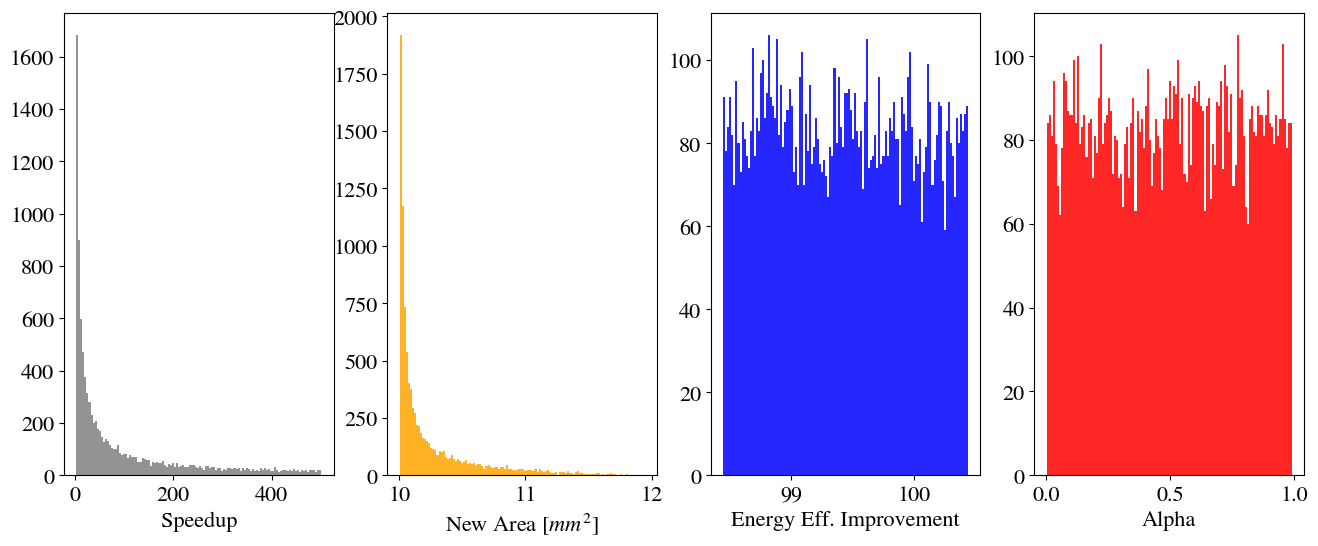

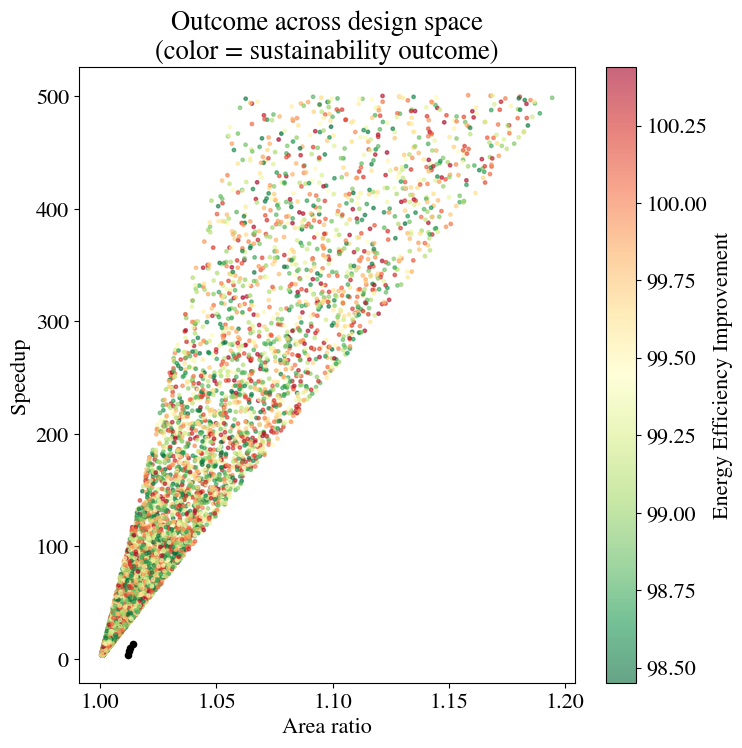

In [58]:

fig, ax = plt.subplots(1,4, figsize=(16,6))

ax[0].hist(speedup, bins=120, color='Gray', alpha=0.85, edgecolor='none')
ax[0].set_xlabel('Speedup')
ax[1].hist(new_area, bins=120, color='Orange', alpha=0.85, edgecolor='none')
ax[1].set_xlabel('New Area [$mm^2$]')
ax[2].hist(1/energy_ratio, bins=120, color='Blue', alpha=0.85, edgecolor='none')
ax[2].set_xlabel('Energy Eff. Improvement')
ax[3].hist(alpha, bins=120, color='Red', alpha=0.85, edgecolor='none')
ax[3].set_xlabel('Alpha')

################################################################################################################

fig, axes = plt.subplots(1,1, figsize=(8, 8))

ax = axes #axes[1, 0]
sc = ax.scatter(area_ratio, speedup, c=1/energy_ratio,
                 cmap='RdYlGn_r', s=6, vmin=np.min(1/energy_ratio), vmax=np.max(1/energy_ratio), alpha=0.6)

plt.colorbar(sc, ax=ax, label='Energy Efficiency Improvement')

for i in range(our_Area.shape[0]):
    ax.scatter (our_area_ratio[i], our_Speedup[i], s = 20, c ='black')

ax.set_xlabel('Area ratio')
ax.set_ylabel('Speedup')
ax.set_title('Outcome across design space\n(color = sustainability outcome)')

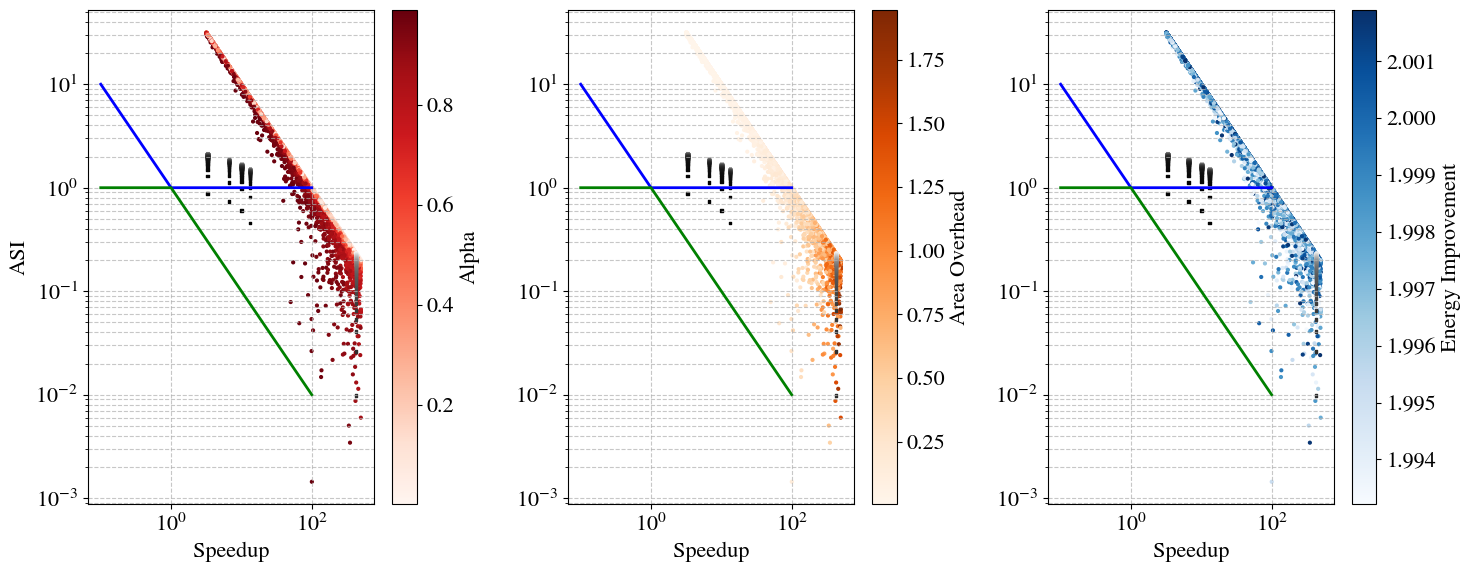

In [59]:
# ----------------------------------------------------------------------
# 3. XASI METRIC
# ----------------------------------------------------------------------

asi_res     = asi_function(alpha=alpha, area_ratio=area_ratio, power_ratio=power_ratio,print=False)

# ASI Framework separations
speedup_space = np.logspace(-1, 2, 100)

sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(15, 6))
ax[0].set_ylabel('ASI')
for this_ax in ax:
    this_ax.loglog(speedup_space, sep_strongly_sustainable, 'b', linewidth=2, label='Strongly Sustainable')
    this_ax.loglog(speedup_space, sep_weakly_sustainable,   'g', linewidth=2, label='Weakly Sustainable')

    this_ax.set_xlabel('Speedup')
    this_ax.grid(True, which='both', linestyle='--', alpha=0.7)
    #this_ax.set_xlim(10, 1e7)

# Add our accelerator
p = ax[0].scatter(speedup,   asi_res,   c=alpha,cmap="Reds",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[0],orientation='vertical',label='Alpha')

p = ax[1].scatter(speedup,   asi_res,   c=area_overhead,cmap="Oranges",  s=4, label='Our Accelerator') #np.log10(area_overhead)
fig.colorbar(p,ax=ax[1],orientation='vertical',label='Area Overhead')

p = ax[2].scatter(speedup,   asi_res,   c=np.log10(1/energy_ratio),cmap="Blues",  s=4, label='Our Accelerator')
fig.colorbar(p,ax=ax[2],orientation='vertical',label='Energy Improvement')


# Add our accelerator
for i in range(our_area_ratio.shape[0]):
    p = ax[0].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[1].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
    p = ax[2].scatter(np.ones(len(alpha_studied))*our_speedup_ratio[i],   np.maximum(our_asi_res[:,i],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')

p = ax[0].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[ref_point_soa],   np.maximum(soa_asi_res[:,ref_point_soa],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[1].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[ref_point_soa],   np.maximum(soa_asi_res[:,ref_point_soa],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
p = ax[2].scatter(np.ones(len(alpha_studied))*soa_speedup_ratio[ref_point_soa],   np.maximum(soa_asi_res[:,ref_point_soa],-1),   c=alpha_studied,cmap="Greys",  s=4, marker='s')
# Add legend
fig.tight_layout()
plt.show()
